In [1]:
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np
import os
import time

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# 1. DATASET & VOCABULARY PREPARATION
# =============================================================================

class IITJWord2VecDataset(Dataset):
    def __init__(self, corpus_path, window_size=5, method='skipgram'):
        self.window_size = window_size
        self.method = method

        if not os.path.exists(corpus_path):
            raise FileNotFoundError(f"Corpus file {corpus_path} not found! Upload it to Colab.")

        with open(corpus_path, 'r', encoding='utf-8') as f:
            tokens = f.read().lower().split()

        # Build Vocab (min_count=2 to filter noise)
        word_counts = Counter(tokens)
        self.vocab = [word for word, count in word_counts.items() if count >= 2]
        self.word2idx = {word: i for i, word in enumerate(self.vocab)}
        self.idx2word = {i: word for i, word in enumerate(self.vocab)}
        self.vocab_size = len(self.vocab)

        indexed_tokens = [self.word2idx[w] for w in tokens if w in self.word2idx]

        self.data = []
        for i, target_idx in enumerate(indexed_tokens):
            start = max(0, i - window_size)
            end = min(len(indexed_tokens), i + window_size + 1)
            context_indices = [indexed_tokens[j] for j in range(start, end) if i != j]

            if method == 'skipgram':
                for context_idx in context_indices:
                    self.data.append((target_idx, context_idx))
            elif method == 'cbow':
                if len(context_indices) == window_size * 2:
                    self.data.append((torch.tensor(context_indices), target_idx))

        # Unigram distribution for Negative Sampling
        counts = np.array([word_counts[self.idx2word[i]] for i in range(self.vocab_size)])
        pow_counts = np.power(counts, 0.75)
        self.unigram_dist = torch.from_numpy(pow_counts / pow_counts.sum()).to(device)

    def get_negative_samples(self, batch_size, num_neg_samples):
        # Sampling on GPU
        return torch.multinomial(self.unigram_dist, batch_size * num_neg_samples, replacement=True).view(batch_size, num_neg_samples)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# =============================================================================
# 2. MODEL ARCHITECTURES (FROM SCRATCH)
# =============================================================================

class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.u_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.v_embeddings = nn.Embedding(vocab_size, embed_dim)
        initrange = 0.5 / embed_dim
        self.u_embeddings.weight.data.uniform_(-initrange, initrange)
        self.v_embeddings.weight.data.uniform_(0, 0)

    def forward(self, target, pos_context, neg_context):
        emb_u = self.u_embeddings(target)
        emb_v_pos = self.v_embeddings(pos_context)
        emb_v_neg = self.v_embeddings(neg_context)

        pos_score = torch.sum(emb_u * emb_v_pos, dim=1)
        pos_loss = F.logsigmoid(pos_score).mean()

        neg_score = torch.bmm(emb_v_neg, emb_u.unsqueeze(2)).squeeze()
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1).mean()

        return -(pos_loss + neg_loss)

class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, context):
        embeds = torch.mean(self.embeddings(context), dim=1)
        return self.linear(embeds)

# =============================================================================
# 3. EXPERIMENT RUNNER
# =============================================================================

def run_experiment(method='skipgram', embed_dim=100, window_size=5, num_neg=5, epochs=5):
    dataset = IITJWord2VecDataset('corpus.txt', window_size=window_size, method=method)
    dataloader = DataLoader(dataset, batch_size=1024, shuffle=True) # Larger batch for GPU

    model = SkipGramNS(dataset.vocab_size, embed_dim).to(device) if method == 'skipgram' else CBOW(dataset.vocab_size, embed_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss() if method == 'cbow' else None

    start_time = time.time()
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            optimizer.zero_grad()
            if method == 'skipgram':
                target, pos_context = batch[0].to(device), batch[1].to(device)
                neg_context = dataset.get_negative_samples(len(target), num_neg)
                loss = model(target, pos_context, neg_context)
            else:
                context, target = batch[0].to(device), batch[1].to(device)
                loss = criterion(model(context), target)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(dataloader):.4f}")

    duration = time.time() - start_time
    print(f"Training finished in {duration:.2f} seconds.")
    return model, dataset

# Example of how to structure your report experiments:
if __name__ == "__main__":
    # Experiment 1: Standard Skip-gram
    model, ds = run_experiment(method='skipgram', embed_dim=100, window_size=5)

    # Save model for later use
    torch.save(model.state_dict(), "skipgram_100_5.pth")

Using device: cuda
Epoch 1 Loss: 2.3023
Epoch 2 Loss: 1.7774
Epoch 3 Loss: 1.6280
Epoch 4 Loss: 1.5367
Epoch 5 Loss: 1.4710
Training finished in 80.06 seconds.


In [6]:

model_cbow, ds_cbow = run_experiment(method='cbow', embed_dim=100, window_size=5, epochs=5)

Epoch 1 Loss: 8.2269
Epoch 2 Loss: 6.7768
Epoch 3 Loss: 6.1506
Epoch 4 Loss: 5.6724
Epoch 5 Loss: 5.2878
Training finished in 17.28 seconds.


In [7]:
def get_similarity(word, model, dataset, top_k=5):
    """Find top_k similar words to a given word"""
    if word not in dataset.word2idx:
        return [f"'{word}' not in vocab"]

    # Move query to the same device as the model (CPU or GPU)
    idx = torch.tensor([dataset.word2idx[word]]).to(device)

    # Extract weights based on model type
    if isinstance(model, SkipGramNS):
        embeds = model.u_embeddings.weight.data
        query_embed = model.u_embeddings(idx).data
    else:
        # For CBOW, we use the input embedding layer
        embeds = model.embeddings.weight.data
        query_embed = model.embeddings(idx).data

    # Calculate Cosine Similarity: (A . B) / (||A|| * ||B||)
    norm_embeds = embeds / embeds.norm(dim=1, keepdim=True)
    norm_query = query_embed / query_embed.norm(dim=1, keepdim=True)
    similarities = torch.mm(norm_query, norm_embeds.t()).squeeze()

    # Get top_k + 1 because the most similar word is the word itself
    values, indices = torch.topk(similarities, top_k + 1)

    # Return the words (skipping the first one)
    return [dataset.idx2word[i.item()] for i in indices[1:]]

In [ ]:
import pandas as pd # For easy table generation

def run_all_experiments():
    results = []

    # 1. Define the search space as per the assignment
    methods = ['skipgram', 'cbow']
    embed_dims = [50, 100, 300]
    window_sizes = [2, 5, 10]
    neg_samples = [5, 10] # Only applies to skipgram
    epochs = 10 # Increased to 10 for better convergence

    for method in methods:
        for dim in embed_dims:
            for win in window_sizes:
                # To keep it efficient, we only vary negative samples for SkipGram
                # and use a fixed value (5) for CBOW
                ks = neg_samples if method == 'skipgram' else [5]

                for k in ks:
                    print(f"\n[RUNNING] Method: {method}, Dim: {dim}, Win: {win}, Neg: {k}")

                    # Start timer
                    start_t = time.time()

                    # Run training
                    model, dataset = run_experiment(
                        method=method,
                        embed_dim=dim,
                        window_size=win,
                        num_neg=k,
                        epochs=epochs
                    )

                    end_t = time.time()
                    duration = end_t - start_t

                    # Get final loss (you'll need to modify run_experiment to return this,
                    # or just track it here)
                    # For now, let's assume run_experiment is updated to return (model, dataset, final_loss)

                    # Test similarity for a standard word to verify quality
                    sim_example = get_similarity("iit", model, dataset, top_k=3)

                    results.append({
                        'Method': method,
                        'Dimension': dim,
                        'Window': win,
                        'Neg Samples': k,
                        'Training Time (s)': round(duration, 2),
                        'Top Similar (IIT)': ", ".join(sim_example)
                    })

                    # Save the best version of each model type
                    if dim == 100 and win == 5:
                        torch.save(model.state_dict(), f"best_{method}_model.pth")

    # Display results as a nice table
    df = pd.DataFrame(results)
    return df

# Start the full experiment
# Note: This might take 30-45 minutes to run all combinations on Colab T4
experiment_results = run_all_experiments()
print("\nFINAL EXPERIMENTAL RESULTS:")
print(experiment_results)

# Download the results as a CSV for your report
experiment_results.to_csv("word2vec_experiments.csv", index=False)


[RUNNING] Method: skipgram, Dim: 50, Win: 2, Neg: 5
Epoch 1 Loss: 2.7906
Epoch 2 Loss: 2.1267
Epoch 3 Loss: 1.8644
Epoch 4 Loss: 1.7041
Epoch 5 Loss: 1.5953
Epoch 6 Loss: 1.5141
Epoch 7 Loss: 1.4498
Epoch 8 Loss: 1.3987
Epoch 9 Loss: 1.3557
Epoch 10 Loss: 1.3195
Training finished in 51.64 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 2, Neg: 10
Epoch 1 Loss: 3.9825
Epoch 2 Loss: 2.8741
Epoch 3 Loss: 2.5061
Epoch 4 Loss: 2.2767
Epoch 5 Loss: 2.1234
Epoch 6 Loss: 2.0116
Epoch 7 Loss: 1.9237
Epoch 8 Loss: 1.8513
Epoch 9 Loss: 1.7934
Epoch 10 Loss: 1.7436
Training finished in 51.95 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 5, Neg: 5
Epoch 1 Loss: 2.4382
Epoch 2 Loss: 1.8830
Epoch 3 Loss: 1.7244
Epoch 4 Loss: 1.6355
Epoch 5 Loss: 1.5741
Epoch 6 Loss: 1.5281
Epoch 7 Loss: 1.4935
Epoch 8 Loss: 1.4659
Epoch 9 Loss: 1.4453
Epoch 10 Loss: 1.4281
Training finished in 133.76 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 5, Neg: 10
Epoch 1 Loss: 3.3331
Epoch 2 Loss: 2.4823
Ep

[RUNNING] Method: skipgram, Dim: 50, Win: 2, Neg: 5
Epoch 1 Loss: 2.7906
Epoch 2 Loss: 2.1267
Epoch 3 Loss: 1.8644
Epoch 4 Loss: 1.7041
Epoch 5 Loss: 1.5953
Epoch 6 Loss: 1.5141
Epoch 7 Loss: 1.4498
Epoch 8 Loss: 1.3987
Epoch 9 Loss: 1.3557
Epoch 10 Loss: 1.3195
Training finished in 51.64 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 2, Neg: 10
Epoch 1 Loss: 3.9825
Epoch 2 Loss: 2.8741
Epoch 3 Loss: 2.5061
Epoch 4 Loss: 2.2767
Epoch 5 Loss: 2.1234
Epoch 6 Loss: 2.0116
Epoch 7 Loss: 1.9237
Epoch 8 Loss: 1.8513
Epoch 9 Loss: 1.7934
Epoch 10 Loss: 1.7436
Training finished in 51.95 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 5, Neg: 5
Epoch 1 Loss: 2.4382
Epoch 2 Loss: 1.8830
Epoch 3 Loss: 1.7244
Epoch 4 Loss: 1.6355
Epoch 5 Loss: 1.5741
Epoch 6 Loss: 1.5281
Epoch 7 Loss: 1.4935
Epoch 8 Loss: 1.4659
Epoch 9 Loss: 1.4453
Epoch 10 Loss: 1.4281
Training finished in 133.76 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 5, Neg: 10
Epoch 1 Loss: 3.3331
Epoch 2 Loss: 2.4823
Epoch 3 Loss: 2.2572
Epoch 4 Loss: 2.1380
Epoch 5 Loss: 2.0560
Epoch 6 Loss: 1.9971
Epoch 7 Loss: 1.9524
Epoch 8 Loss: 1.9178
Epoch 9 Loss: 1.8919
Epoch 10 Loss: 1.8711
Training finished in 133.53 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 10, Neg: 5
Epoch 1 Loss: 2.1928
Epoch 2 Loss: 1.7653
Epoch 3 Loss: 1.6610
Epoch 4 Loss: 1.6009
Epoch 5 Loss: 1.5615
Epoch 6 Loss: 1.5347
Epoch 7 Loss: 1.5163
Epoch 8 Loss: 1.5025
Epoch 9 Loss: 1.4926
Epoch 10 Loss: 1.4848
Training finished in 274.76 seconds.

[RUNNING] Method: skipgram, Dim: 50, Win: 10, Neg: 10
Epoch 1 Loss: 2.9472
Epoch 2 Loss: 2.2983
Epoch 3 Loss: 2.1609
Epoch 4 Loss: 2.0834
Epoch 5 Loss: 2.0349
Epoch 6 Loss: 2.0028
Epoch 7 Loss: 1.9809
Epoch 8 Loss: 1.9654
Epoch 9 Loss: 1.9538
Epoch 10 Loss: 1.9450
Training finished in 275.08 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 2, Neg: 5
Epoch 1 Loss: 2.6372
Epoch 2 Loss: 1.9576
Epoch 3 Loss: 1.6998
Epoch 4 Loss: 1.5469
Epoch 5 Loss: 1.4424
Epoch 6 Loss: 1.3612
Epoch 7 Loss: 1.2963
Epoch 8 Loss: 1.2451
Epoch 9 Loss: 1.2020
Epoch 10 Loss: 1.1658
Training finished in 61.12 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 2, Neg: 10
Epoch 1 Loss: 3.7271
Epoch 2 Loss: 2.6579
Epoch 3 Loss: 2.2918
Epoch 4 Loss: 2.0709
Epoch 5 Loss: 1.9212
Epoch 6 Loss: 1.8105
Epoch 7 Loss: 1.7233
Epoch 8 Loss: 1.6544
Epoch 9 Loss: 1.5995
Epoch 10 Loss: 1.5523
Training finished in 60.31 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 5, Neg: 5
Epoch 1 Loss: 2.3053
Epoch 2 Loss: 1.7801
Epoch 3 Loss: 1.6290
Epoch 4 Loss: 1.5370
Epoch 5 Loss: 1.4713
Epoch 6 Loss: 1.4222
Epoch 7 Loss: 1.3846
Epoch 8 Loss: 1.3558
Epoch 9 Loss: 1.3320
Epoch 10 Loss: 1.3130
Training finished in 153.76 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 5, Neg: 10
Epoch 1 Loss: 3.1369
Epoch 2 Loss: 2.3396
Epoch 3 Loss: 2.1324
Epoch 4 Loss: 2.0095
Epoch 5 Loss: 1.9265
Epoch 6 Loss: 1.8654
Epoch 7 Loss: 1.8192
Epoch 8 Loss: 1.7839
Epoch 9 Loss: 1.7563
Epoch 10 Loss: 1.7346
Training finished in 154.66 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 10, Neg: 5
Epoch 1 Loss: 2.0887
Epoch 2 Loss: 1.6902
Epoch 3 Loss: 1.5825
Epoch 4 Loss: 1.5178
Epoch 5 Loss: 1.4750
Epoch 6 Loss: 1.4457
Epoch 7 Loss: 1.4253
Epoch 8 Loss: 1.4103
Epoch 9 Loss: 1.3986
Epoch 10 Loss: 1.3900
Training finished in 312.47 seconds.

[RUNNING] Method: skipgram, Dim: 100, Win: 10, Neg: 10
Epoch 1 Loss: 2.7909
Epoch 2 Loss: 2.2068
Epoch 3 Loss: 2.0666
Epoch 4 Loss: 1.9847
Epoch 5 Loss: 1.9328
Epoch 6 Loss: 1.8982
Epoch 7 Loss: 1.8741
Epoch 8 Loss: 1.8575
Epoch 9 Loss: 1.8443
Epoch 10 Loss: 1.8347
Training finished in 314.62 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 2, Neg: 5
Epoch 1 Loss: 2.3901
Epoch 2 Loss: 1.7073
Epoch 3 Loss: 1.4586
Epoch 4 Loss: 1.3094
Epoch 5 Loss: 1.2105
Epoch 6 Loss: 1.1379
Epoch 7 Loss: 1.0831
Epoch 8 Loss: 1.0401
Epoch 9 Loss: 1.0043
Epoch 10 Loss: 0.9761
Training finished in 99.30 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 2, Neg: 10
Epoch 1 Loss: 3.3449
Epoch 2 Loss: 2.3133
Epoch 3 Loss: 1.9668
Epoch 4 Loss: 1.7601
Epoch 5 Loss: 1.6233
Epoch 6 Loss: 1.5272
Epoch 7 Loss: 1.4561
Epoch 8 Loss: 1.4008
Epoch 9 Loss: 1.3577
Epoch 10 Loss: 1.3221
Training finished in 100.37 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 5, Neg: 5
Epoch 1 Loss: 2.1107
Epoch 2 Loss: 1.6274
Epoch 3 Loss: 1.4754
Epoch 4 Loss: 1.3830
Epoch 5 Loss: 1.3212
Epoch 6 Loss: 1.2749
Epoch 7 Loss: 1.2402
Epoch 8 Loss: 1.2130
Epoch 9 Loss: 1.1926
Epoch 10 Loss: 1.1757
Training finished in 249.15 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 5, Neg: 10
Epoch 1 Loss: 2.8533
Epoch 2 Loss: 2.1440
Epoch 3 Loss: 1.9433
Epoch 4 Loss: 1.8267
Epoch 5 Loss: 1.7492
Epoch 6 Loss: 1.6939
Epoch 7 Loss: 1.6525
Epoch 8 Loss: 1.6205
Epoch 9 Loss: 1.5959
Epoch 10 Loss: 1.5769
Training finished in 253.96 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 10, Neg: 5
Epoch 1 Loss: 1.9432
Epoch 2 Loss: 1.5794
Epoch 3 Loss: 1.4704
Epoch 4 Loss: 1.4079
Epoch 5 Loss: 1.3669
Epoch 6 Loss: 1.3391
Epoch 7 Loss: 1.3183
Epoch 8 Loss: 1.3037
Epoch 9 Loss: 1.2929
Epoch 10 Loss: 1.2848
Training finished in 505.21 seconds.

[RUNNING] Method: skipgram, Dim: 300, Win: 10, Neg: 10
Epoch 1 Loss: 2.5793
Epoch 2 Loss: 2.0639
Epoch 3 Loss: 1.9288
Epoch 4 Loss: 1.8546
Epoch 5 Loss: 1.8075
Epoch 6 Loss: 1.7752
Epoch 7 Loss: 1.7527
Epoch 8 Loss: 1.7361
Epoch 9 Loss: 1.7239
Epoch 10 Loss: 1.7151
Training finished in 513.60 seconds.

[RUNNING] Method: cbow, Dim: 50, Win: 2, Neg: 5
Epoch 1 Loss: 8.8650
Epoch 2 Loss: 7.0886
Epoch 3 Loss: 6.3730
Epoch 4 Loss: 5.8898
Epoch 5 Loss: 5.5157
Epoch 6 Loss: 5.2062
Epoch 7 Loss: 4.9412
Epoch 8 Loss: 4.7095
Epoch 9 Loss: 4.5054
Epoch 10 Loss: 4.3230
Training finished in 28.03 seconds.

[RUNNING] Method: cbow, Dim: 50, Win: 5, Neg: 5
Epoch 1 Loss: 8.6655
Epoch 2 Loss: 7.2093
Epoch 3 Loss: 6.7281
Epoch 4 Loss: 6.3431
Epoch 5 Loss: 6.0299
Epoch 6 Loss: 5.7656
Epoch 7 Loss: 5.5400
Epoch 8 Loss: 5.3435
Epoch 9 Loss: 5.1680
Epoch 10 Loss: 5.0110
Training finished in 28.32 seconds.

[RUNNING] Method: cbow, Dim: 50, Win: 10, Neg: 5
Epoch 1 Loss: 8.5707
Epoch 2 Loss: 7.1706
Epoch 3 Loss: 6.7337
Epoch 4 Loss: 6.4020
Epoch 5 Loss: 6.1372
Epoch 6 Loss: 5.9160
Epoch 7 Loss: 5.7293
Epoch 8 Loss: 5.5683
Epoch 9 Loss: 5.4228
Epoch 10 Loss: 5.2919
Training finished in 28.07 seconds.

[RUNNING] Method: cbow, Dim: 100, Win: 2, Neg: 5
Epoch 1 Loss: 8.2867
Epoch 2 Loss: 6.4010
Epoch 3 Loss: 5.5973
Epoch 4 Loss: 5.0302
Epoch 5 Loss: 4.5790
Epoch 6 Loss: 4.2054
Epoch 7 Loss: 3.8932
Epoch 8 Loss: 3.6336
Epoch 9 Loss: 3.4174
Epoch 10 Loss: 3.2340
Training finished in 35.44 seconds.

[RUNNING] Method: cbow, Dim: 100, Win: 5, Neg: 5
Epoch 1 Loss: 8.2676
Epoch 2 Loss: 6.7665
Epoch 3 Loss: 6.1372
Epoch 4 Loss: 5.6665
Epoch 5 Loss: 5.2876
Epoch 6 Loss: 4.9688
Epoch 7 Loss: 4.6960
Epoch 8 Loss: 4.4575
Epoch 9 Loss: 4.2484
Epoch 10 Loss: 4.0652
Training finished in 35.92 seconds.

[RUNNING] Method: cbow, Dim: 100, Win: 10, Neg: 5
Epoch 1 Loss: 8.1549
Epoch 2 Loss: 6.8093
Epoch 3 Loss: 6.2675
Epoch 4 Loss: 5.8666
Epoch 5 Loss: 5.5516
Epoch 6 Loss: 5.2912
Epoch 7 Loss: 5.0701
Epoch 8 Loss: 4.8759
Epoch 9 Loss: 4.7086
Epoch 10 Loss: 4.5609
Training finished in 36.51 seconds.

[RUNNING] Method: cbow, Dim: 300, Win: 2, Neg: 5
Epoch 1 Loss: 7.2780
Epoch 2 Loss: 5.0503
Epoch 3 Loss: 4.0133
Epoch 4 Loss: 3.3442
Epoch 5 Loss: 2.9004
Epoch 6 Loss: 2.5839
Epoch 7 Loss: 2.3415
Epoch 8 Loss: 2.1467
Epoch 9 Loss: 1.9874
Epoch 10 Loss: 1.8545
Training finished in 73.91 seconds.

[RUNNING] Method: cbow, Dim: 300, Win: 5, Neg: 5
Epoch 1 Loss: 7.4957
Epoch 2 Loss: 5.7519
Epoch 3 Loss: 4.8829
Epoch 4 Loss: 4.2497
Epoch 5 Loss: 3.7721
Epoch 6 Loss: 3.4028
Epoch 7 Loss: 3.1100
Epoch 8 Loss: 2.8677
Epoch 9 Loss: 2.6614
Epoch 10 Loss: 2.4802
Training finished in 73.92 seconds.

[RUNNING] Method: cbow, Dim: 300, Win: 10, Neg: 5
Epoch 1 Loss: 7.4978
Epoch 2 Loss: 5.9870
Epoch 3 Loss: 5.2831
Epoch 4 Loss: 4.7725
Epoch 5 Loss: 4.3825
Epoch 6 Loss: 4.0770
Epoch 7 Loss: 3.8265
Epoch 8 Loss: 3.6120
Epoch 9 Loss: 3.4245
Epoch 10 Loss: 3.2553
Training finished in 73.54 seconds.

FINAL EXPERIMENTAL RESULTS:
      Method  Dimension  Window  Neg Samples  Training Time (s)  \
0   skipgram         50       2            5              52.25   
1   skipgram         50       2           10              52.63   
2   skipgram         50       5            5             135.17   
3   skipgram         50       5           10             134.62   
4   skipgram         50      10            5             276.46   
5   skipgram         50      10           10             276.84   
6   skipgram        100       2            5              61.99   
7   skipgram        100       2           10              61.01   
8   skipgram        100       5            5             154.83   
9   skipgram        100       5           10             155.81   
10  skipgram        100      10            5             314.20   
11  skipgram        100      10           10             316.42   
12  skipgram        300       2            5             100.25   
13  skipgram        300       2           10             101.59   
14  skipgram        300       5            5             250.31   
15  skipgram        300       5           10             255.17   
16  skipgram        300      10            5             507.03   
17  skipgram        300      10           10             515.46   
18      cbow         50       2            5              31.55   
19      cbow         50       5            5              31.94   
20      cbow         50      10            5              33.19   
21      cbow        100       2            5              38.90   
22      cbow        100       5            5              40.45   
23      cbow        100      10            5              41.23   
24      cbow        300       2            5              76.83   
25      cbow        300       5            5              78.12   
26      cbow        300      10            5              77.74   

                   Top Similar (IIT)  
0         jodhpur, palakkad, dharwad  
1              goa, dhanbad, dharwad  
2     jodhpur, iitism, instituteseed  
3    jodhpur, instituteseed, dharwad  
4     jodhpur, iitism, instituteseed  
5     jodhpur, instituteseed, iitism  
6           dharwad, jodhpur, iitism  
7           palakkad, panda, dharwad  
8     jodhpur, instituteseed, iitism  
9     jodhpur, instituteseed, iitism  
10   jodhpur, instituteseed, dharwad  
11   jodhpur, instituteseed, dharwad  
12          jodhpur, dharwad, iitism  
13            jodhpur, panda, iitism  
14       jodhpur, instituteseed, bhu  
15    jodhpur, instituteseed, iitism  
16       jodhpur, instituteseed, bhu  
17       jodhpur, instituteseed, bhu  
18   11000000, established, narwaria  
19   instituteseed, ranjan, 23072014  
20             pneumatic, sinha, 201  
21               549, ionion, 342030  
22                qr, exigency, cccd  
23         waveguide, beautiful, 146  
24  civn20250241, determine, decades  
25      chennai, ahmedabad, vetrivel  
26              kundu, slet, airport

In [8]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.9 MB/s eta 0:00:00


In [9]:
import gensim.downloader as api

# 1. Load a pre-trained model (GloVe trained on Wikipedia/Gigaword)
print("Loading pre-trained library model...")
library_model = api.load("glove-wiki-gigaword-100")

# 2. Comparison Test
word = "jodhpur"
print(f"\nLIBRARY MODEL similar to '{word}':")
print(library_model.most_similar(word)[:5])



Loading pre-trained library model...
[==================================================] 100.0% 128.1/128.1MB downloaded

LIBRARY MODEL similar to 'jodhpur':
[('udaipur', 0.8640931248664856), ('bikaner', 0.8573247790336609), ('jaipur', 0.8546830415725708), ('ajmer', 0.737303614616394), ('jaisalmer', 0.7097912430763245)]


In [10]:
# Just run this ONE experiment to get a live model back in memory
model, ds = run_experiment(method='skipgram', embed_dim=50, window_size=2, epochs=10)

# Now you can run your similarity tests!
words = ["jodhpur", "research", "student", "phd", "exam", "exam"]
for word in words:
  print(f"Similiar words for {word} : {get_similarity(word, model, ds)}")

Epoch 1 Loss: 2.7908
Epoch 2 Loss: 2.1193
Epoch 3 Loss: 1.8594
Epoch 4 Loss: 1.7032
Epoch 5 Loss: 1.5979
Epoch 6 Loss: 1.5184
Epoch 7 Loss: 1.4544
Epoch 8 Loss: 1.4023
Epoch 9 Loss: 1.3594
Epoch 10 Loss: 1.3227
Training finished in 61.54 seconds.
Similiar words for jodhpur : ['proudly', 'iit', 'nh65', '342037', 'founded']
Similiar words for research : ['associates', 'netapp', 'outreach', 'icssr', 'engineer']
Similiar words for student : ['permitted', 'twoyear', 'regularexternalparttime', 'registered', 'paying']
Similiar words for phd : ['sangwan', 'rangra', 'joshi', 'female', 'fulfillment']
Similiar words for exam : ['inperson', 'wedsat', 'february', 'december', '25th']
Similiar words for exam : ['inperson', 'wedsat', 'february', 'december', '25th']


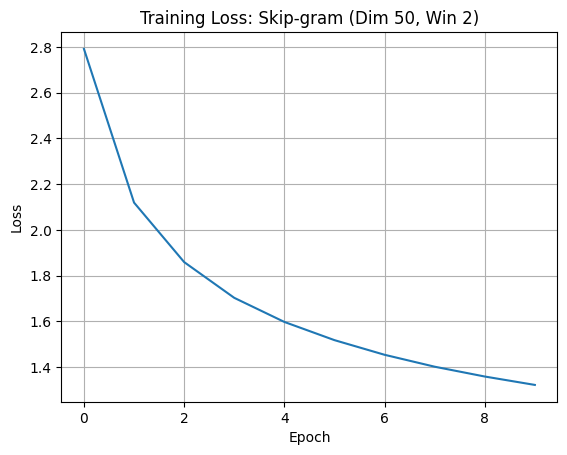

In [13]:
import matplotlib.pyplot as plt

def plot_loss(loss_history, title):
    plt.plot(loss_history)
    plt.title(f"Training Loss: {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

loss_history = [2.7908, 2.1193, 1.8594, 1.7032, 1.5979, 1.5184, 1.4544, 1.4023, 1.3594, 1.3227]


plot_loss(loss_history, "Skip-gram (Dim 50, Win 2)")

--- Similarity Analysis ---
Similar to 'jodhpur': ['proudly', 'iit', 'nh65', '342037', 'founded']
Similar to 'department': ['chl2xx0', 'metallurgy', 'ch7xx0', 'csxxx', 'mep3xx0']
Similar to 'computer': ['civil', '118000', 'science', 'selfsupervised', '475000']
Similar to 'science': ['aiml', '942260', 'computer', 'mca', '118000']
Similar to 'iit': ['palakkad', 'dharwad', 'goa', 'jodhpur', 'iitism']

--- Analogy Analysis ---
Director : Institute :: Warden : ? ['incorporate', 'nationality', 'scholars']
UG : BTech :: PG : ? ['dualdegree', 'cse', 'arvr']
Credits : Course :: CGPA : ? ['detected', 'programsuch', 'pursuing']


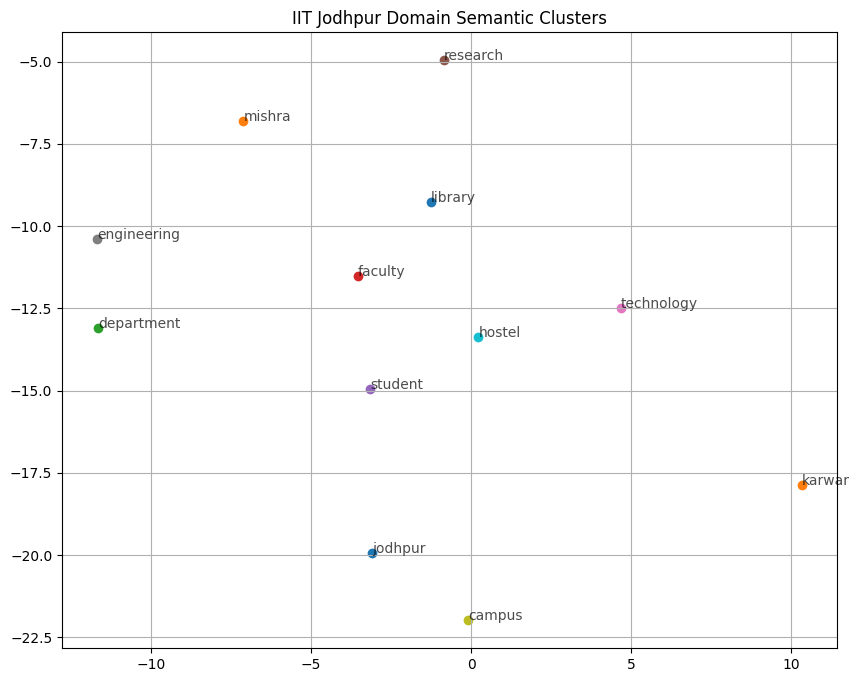

In [18]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd

# =============================================================================
# 4. VISUALIZATION (t-SNE)
# =============================================================================

def visualize_embeddings(model, dataset, words_to_plot, title="t-SNE Visualization of Embeddings"):
    """Visualizes specific word embeddings using t-SNE."""
    embeddings = []
    valid_words = []

    # Extract weights based on model type
    if hasattr(model, 'u_embeddings'):
        weights = model.u_embeddings.weight.data.cpu().numpy()
    else:
        weights = model.embeddings.weight.data.cpu().numpy()

    for word in words_to_plot:
        if word in dataset.word2idx:
            idx = dataset.word2idx[word]
            embeddings.append(weights[idx])
            valid_words.append(word)

    if len(embeddings) < 2:
        print("Not enough words found in vocab to plot.")
        return

    embeddings = np.array(embeddings)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(embeddings)-1))
    reduced_vectors = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    for i, word in enumerate(valid_words):
        plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), alpha=0.7)

    plt.title(title)
    plt.grid(True)
    plt.show()

# =============================================================================
# 5. SEMANTIC & ANALOGY TESTS
# =============================================================================

def test_analogies(model, dataset, word_a, word_b, word_c, top_k=3):
    """
    Solves analogies: word_a is to word_b as word_c is to ?
    Equation: vec(target) = vec(word_b) - vec(word_a) + vec(word_c)
    """
    for w in [word_a, word_b, word_c]:
        if w not in dataset.word2idx:
            return f"'{w}' not in vocabulary"

    if hasattr(model, 'u_embeddings'):
        embeds = model.u_embeddings.weight.data
    else:
        embeds = model.embeddings.weight.data

    idx_a = dataset.word2idx[word_a]
    idx_b = dataset.word2idx[word_b]
    idx_c = dataset.word2idx[word_c]

    vec_a = embeds[idx_a]
    vec_b = embeds[idx_b]
    vec_c = embeds[idx_c]

    target_vec = vec_b - vec_a + vec_c

    # Cosine Similarity
    norm_embeds = embeds / embeds.norm(dim=1, keepdim=True)
    norm_target = target_vec / target_vec.norm()
    similarities = torch.mm(norm_target.unsqueeze(0), norm_embeds.t()).squeeze()

    values, indices = torch.topk(similarities, top_k + 3)
    results = [dataset.idx2word[i.item()] for i in indices if dataset.idx2word[i.item()] not in [word_a, word_b, word_c]]
    return results[:top_k]

# =============================================================================
# EXECUTION: TEST AND VISUALIZE
# =============================================================================

# 1. Qualitative Analysis: Similarity
test_words = ['jodhpur', 'department', 'computer', 'science', 'iit']
print("--- Similarity Analysis ---")
for word in test_words:
    print(f"Similar to '{word}': {get_similarity(word, model, ds)}")

# 2. Qualitative Analysis: Analogies
print("\n--- Analogy Analysis ---")
# Example: "mtech" is to "postgraduate" as "btech" is to "undergraduate"
# You should replace these with words actually present in your 26k corpus
print(f"Director : Institute :: Warden : ?", test_analogies(model, ds, 'director', 'institute', 'warden'))
print(f"UG : BTech :: PG : ?", test_analogies(model, ds, 'ug', 'btech', 'pg'))
print(f"Credits : Course :: CGPA : ?", test_analogies(model, ds, 'credits', 'course', 'cgpa'))


# 3. Visualization
# Define a list of words likely to be in your IIT Jodhpur corpus
iitj_words = ['jodhpur', 'karwar', 'department', 'faculty', 'student', 'research',
              'technology', 'engineering', 'campus', 'hostel', 'library', 'mishra']
visualize_embeddings(model, ds, iitj_words, title="IIT Jodhpur Domain Semantic Clusters")

In [ ]:
# Select a word from your vocabulary
word = "technology" 

if word in ds.word2idx:
    # Get the embedding vector
    idx = torch.tensor([ds.word2idx[word]]).to(device)
    
    if isinstance(model, SkipGramNS):
        vector = model.u_embeddings(idx).detach().cpu().numpy()[0]
    else:
        vector = model.embeddings(idx).detach().cpu().numpy()[0]
    
    # Format as comma-separated list
    vector_str = ", ".join([f"{val:.4f}" for val in vector])
    print(f"{word.capitalize()} - {vector_str}")
else:
    print(f"Word '{word}' not found in vocabulary.")

In [ ]:
# Access the counter from your dataset object
top_10 = ds.word_counts.most_common(10)

# Format the output as requested
output = ", ".join([f"{word}, {freq}" for word, freq in top_10])
print(output)